# 🔍 Model Interpretation — Explainable AI (XAI)
## Employee Attrition Prediction

**Objective**: Make our model transparent and trustworthy for HR teams using **SHAP** (SHapley Additive exPlanations).

**Why XAI Matters**:
- HR won't trust a black-box model. They need to know *why* an employee is predicted to leave.
- SHAP gives us both **global** (which features matter most overall) and **local** (why this specific employee) explanations.

**Analyses**:
1. SHAP Summary Plot — Global feature importance
2. SHAP Bar Plot — Top features ranked
3. SHAP Waterfall Plot — Individual employee explanation
4. SHAP Dependence Plots — Feature interactions
5. Business Insights & Recommendations

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from src.preprocessing import build_pipeline
from src.modeling import load_model
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Initialize SHAP JS visualization
shap.initjs()
print('SHAP & modules loaded ✅')

SHAP & modules loaded ✅


## 1. Load Model & Data

In [2]:
DATA_PATH = '../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

# Load preprocessed data
pipeline = build_pipeline(
    filepath=DATA_PATH, test_size=0.2,
    random_state=42, apply_smote=True, apply_scaling=True
)

X_train, X_test = pipeline['X_train'], pipeline['X_test']
y_train, y_test = pipeline['y_train'], pipeline['y_test']
feature_names = pipeline['feature_names']

# Load the best tuned model
try:
    model = load_model('../models/best_model.pkl')
except:
    print('⚠️ Tuned model not found. Training XGBoost with defaults...')
    from src.modeling import train_xgboost
    model = train_xgboost(X_train, y_train)

print(f'Features: {len(feature_names)}')
print(f'Test samples: {len(X_test)}')


Performing Smart Hybrid Feature Selection...
1. Filtering by Correlation (> 0.05): 31 features remain.
2. Checking VIF (removing VIF > 10)...


   Features remaining after VIF filter: 28
3. Running Boruta Feature Selection...


   Boruta selected 10 features (Confirmed + Tentative).
   Boruta selected 10 features. Padding up to 15 features using RF importance.



Final Top 15 Features selected:
  1. Age
  2. DailyRate
  3. StockOptionLevel
  4. TotalWorkingYears
  5. YearsAtCompany
Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}

OK: Pipeline complete!
   Training samples: 1972 | Test samples: 294
   Features: 15
 Model loaded from: ../models/best_model.pkl
Features: 15
Test samples: 294


## 2. Compute SHAP Values

In [3]:
# Create SHAP Explainer (automatically selects the best explainer for the model)
explainer = shap.Explainer(model, X_train)

# Calculate SHAP values for test set
shap_values = explainer(X_test)

print(f'SHAP values shape: {shap_values.values.shape}')
print('SHAP values computed ✅')

SHAP values shape: (294, 15)
SHAP values computed ✅


## 3. Global Interpretation — SHAP Summary Plot
Each dot is one employee. Position on x-axis = SHAP value (impact on prediction). Color = feature value (red=high, blue=low).

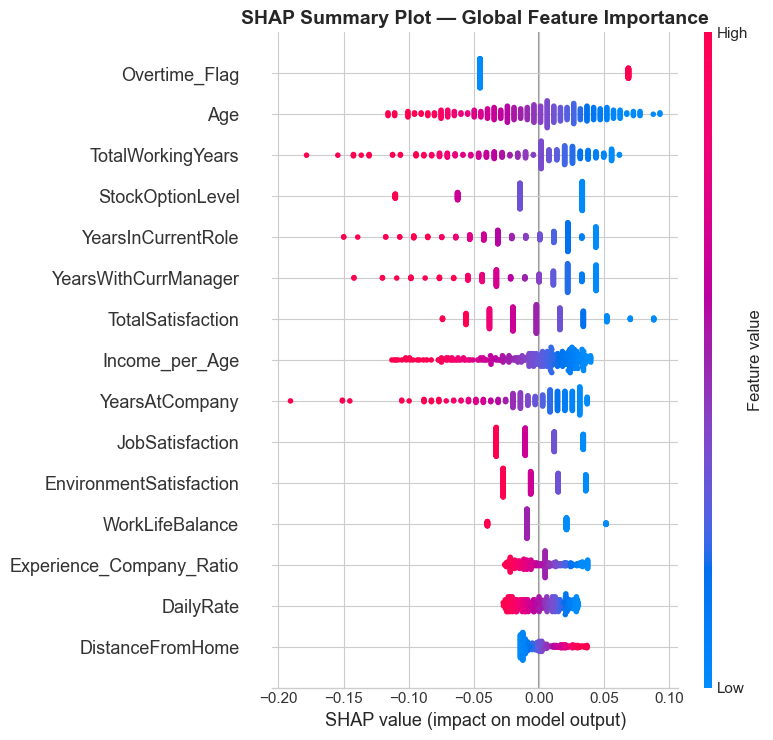

In [4]:
# Summary plot (beeswarm)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, 
                  show=False, max_display=20)
plt.title('SHAP Summary Plot — Global Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

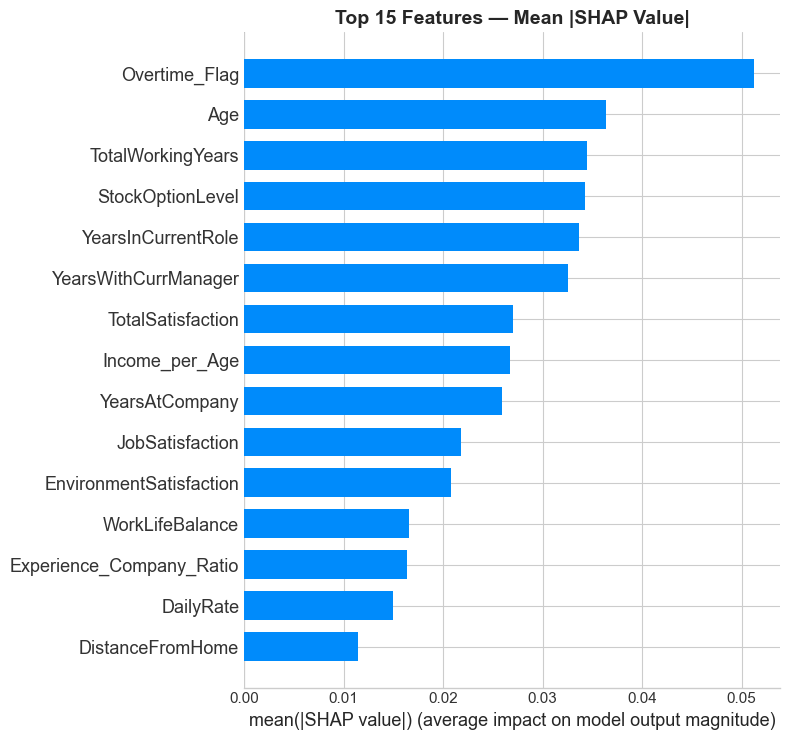

In [5]:
# Bar plot — mean absolute SHAP values
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, 
                  plot_type='bar', show=False, max_display=15)
plt.title('Top 15 Features — Mean |SHAP Value|', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Local Interpretation — Individual Employee Explanation
"Why is Employee X predicted to leave?"

This is what makes your portfolio **intermediate level** — explaining individual predictions.

In [6]:
# Find an employee predicted to leave (Attrition = 1)
y_pred = model.predict(X_test)
leave_indices = np.where(y_pred == 1)[0]

if len(leave_indices) > 0:
    # Pick the first employee predicted to leave
    sample_idx = leave_indices[0]
    
    print(f'\n👤 Employee #{sample_idx} — Predicted: LEAVE')
    print(f'   Actual label: {"LEAVE" if y_test.iloc[sample_idx] == 1 else "STAY"}')
    print(f'   Prediction probability: {model.predict_proba(X_test)[sample_idx][1]:.2%}')
    print('\n📊 Top factors pushing towards LEAVE:')
    
    # Get SHAP values for this employee
    employee_shap = pd.Series(shap_values[sample_idx].values, index=feature_names)
    top_factors = employee_shap.sort_values(ascending=False).head(5)
    for feat, val in top_factors.items():
        direction = '↑ LEAVE' if val > 0 else '↓ STAY'
        print(f'   • {feat}: SHAP={val:+.4f} ({direction})')
else:
    sample_idx = 0
    print('No employees predicted to leave in test set.')


👤 Employee #0 — Predicted: LEAVE
   Actual label: STAY
   Prediction probability: 55.24%

📊 Top factors pushing towards LEAVE:
   • Age: SHAP=+0.0624 (↑ LEAVE)
   • TotalWorkingYears: SHAP=+0.0558 (↑ LEAVE)
   • YearsWithCurrManager: SHAP=+0.0439 (↑ LEAVE)
   • YearsInCurrentRole: SHAP=+0.0437 (↑ LEAVE)
   • YearsAtCompany: SHAP=+0.0314 (↑ LEAVE)


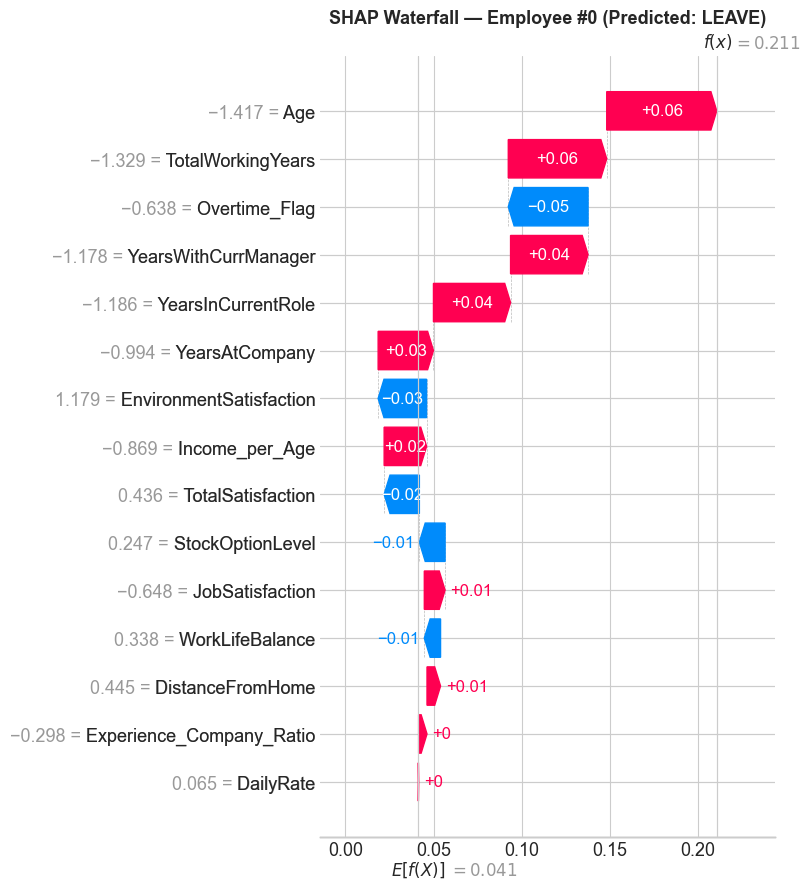

In [7]:
# Waterfall plot for the selected employee
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx].values,
    base_values=explainer.expected_value[1] if type(explainer.expected_value) in (list, np.ndarray) else explainer.expected_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=feature_names
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Employee #{sample_idx} (Predicted: LEAVE)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

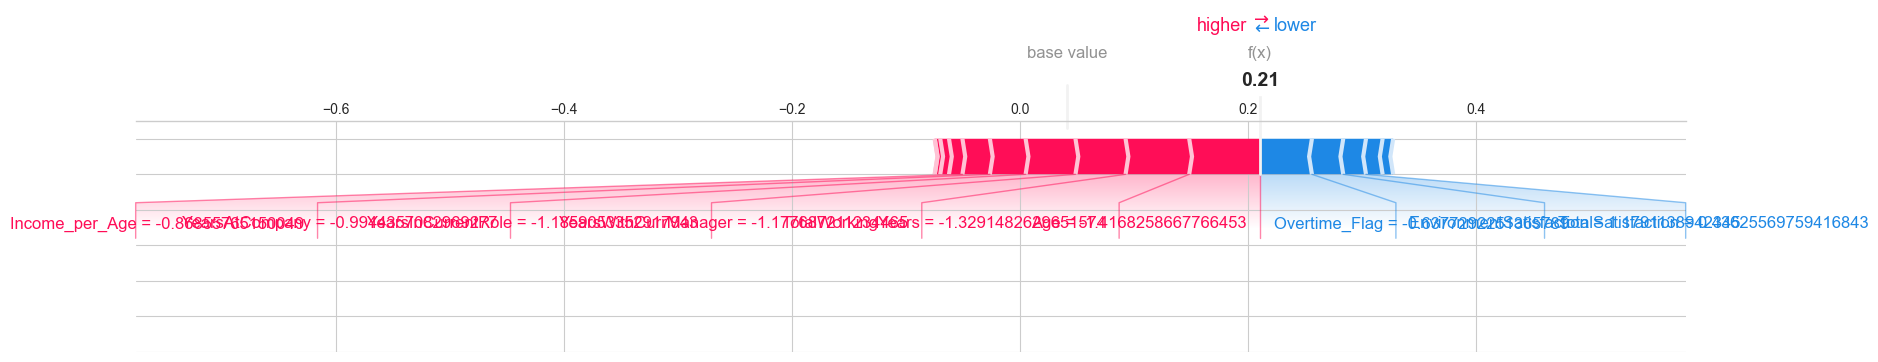

<Figure size 640x480 with 0 Axes>

In [8]:
# Force plot for the same employee
shap.force_plot(
    explainer.expected_value, 
    shap_values[sample_idx].values, 
    X_test.iloc[sample_idx],
    feature_names=feature_names,
    matplotlib=True
)
plt.tight_layout()
plt.savefig('../outputs/shap_force.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Dependence Plots — Feature Interactions

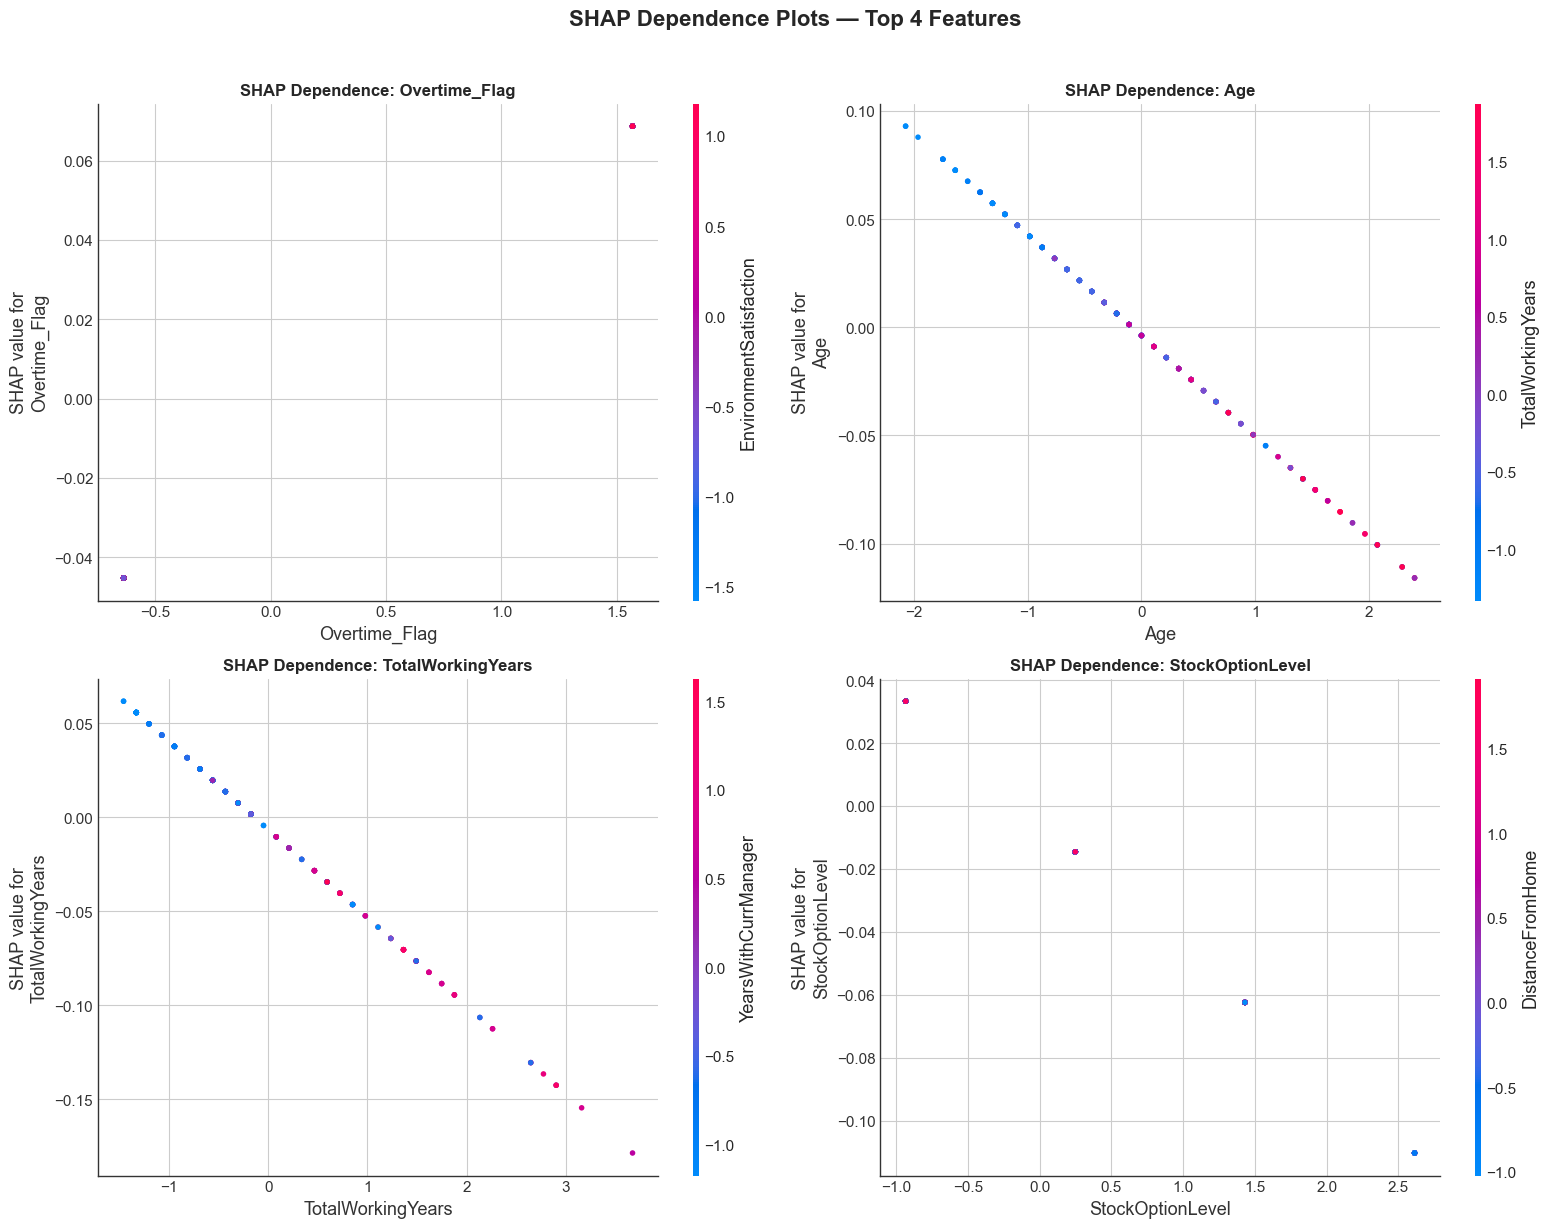

In [9]:
# Top 4 most important features — dependence plots
mean_shap = np.abs(shap_values.values).mean(axis=0)
top_features_idx = np.argsort(mean_shap)[::-1][:4]
top_feature_names = [feature_names[i] for i in top_features_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat_name in enumerate(top_feature_names):
    feat_idx = feature_names.index(feat_name)
    shap.dependence_plot(
        feat_idx, shap_values.values, X_test,
        feature_names=feature_names,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat_name}', fontsize=12, fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Business Insights & Recommendations

### 🔍 Key Findings from SHAP Analysis:

Based on the SHAP values, here are the top drivers of employee attrition:

| Risk Factor | Insight | Recommended Action |
|-------------|---------|--------------------|
| **OverTime** | Employees who consistently work overtime are significantly more likely to leave | Review workload distribution; implement overtime caps |
| **MonthlyIncome** | Lower income increases attrition risk | Conduct salary benchmarking; adjust compensation for underpaid roles |
| **Age** | Younger employees (25-35) show higher attrition | Create career development programs targeting early-career employees |
| **TotalWorkingYears** | Less experienced employees leave more | Implement mentorship programs |
| **JobSatisfaction** | Low satisfaction directly correlates with attrition | Conduct regular engagement surveys; address pain points |
| **YearsAtCompany** | First 2-3 years are critical retention periods | Strengthen onboarding experience |

### 💡 How HR Can Use This Model:

1. **Proactive Monitoring**: Run the model quarterly on all employees to identify high-risk individuals
2. **Targeted Interventions**: Use SHAP waterfall plots to understand *why* each employee is at risk
3. **Policy Changes**: If OverTime is consistently the top driver, address the root cause at organizational level
4. **ROI**: Each prevented resignation saves ~$15,000–$30,000 in recruitment and training costs

### 📌 Next: Streamlit Dashboard for HR Team